# Day 2 - CNN from scratch: Chest X-Ray Pneumonia

In [ ]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchinfo import summary
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 128
BATCH_SIZE = 64
EPOCHS = 20
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists(): PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT = PROJECT_ROOT / "data" / "chest_xray"
MODELS_DIR = PROJECT_ROOT / "models"; REPORTS_DIR = PROJECT_ROOT / "reports"
MODELS_DIR.mkdir(exist_ok=True); REPORTS_DIR.mkdir(exist_ok=True)
print("device:", DEVICE)

device: cpu


## Build and save one fixed stratified split


In [2]:
def collect_images(root):
    rows=[]
    for label, class_name in enumerate(["NORMAL", "PNEUMONIA"]):
        for p in sorted((root / "train" / class_name).glob("*")):
            if p.suffix.lower() in {".jpeg", ".jpg", ".png"}: rows.append({"path": str(p.resolve()), "label": label, "class_name": class_name})
    if not rows: raise FileNotFoundError(f"No train images found under {root / 'train'}")
    return pd.DataFrame(rows)

all_images = collect_images(DATA_ROOT)
train_df, temp_df = train_test_split(all_images, test_size=0.30, stratify=all_images["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)
train_df=train_df.assign(split="train"); val_df=val_df.assign(split="val"); test_df=test_df.assign(split="test")
splits = pd.concat([train_df,val_df,test_df], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
splits.to_csv(PROJECT_ROOT / "splits.csv", index=False)
print(splits.groupby(["split","class_name"]).size())
assert len(splits)==len(all_images) and set(splits.split)=={"train","val","test"}

split  class_name
test   NORMAL         203
       PNEUMONIA      582
train  NORMAL         944
       PNEUMONIA     2718
val    NORMAL         202
       PNEUMONIA      583
dtype: int64


## Dataset and normalization


In [3]:
NORMALIZE = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
transform = transforms.Compose([transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), transforms.Grayscale(num_output_channels=3), transforms.ToTensor(), NORMALIZE])
class XRayDataset(Dataset):
    def __init__(self, frame, transform): self.frame=frame.reset_index(drop=True); self.transform=transform
    def __len__(self): return len(self.frame)
    def __getitem__(self, idx):
        row=self.frame.iloc[idx]
        image=Image.open(row.path).convert("L")
        return self.transform(image), torch.tensor(row.label, dtype=torch.long)

train_data=XRayDataset(splits[splits.split=="train"], transform); val_data=XRayDataset(splits[splits.split=="val"], transform)
train_loader=DataLoader(train_data,batch_size=BATCH_SIZE,shuffle=True,num_workers=0)
val_loader=DataLoader(val_data,batch_size=BATCH_SIZE,shuffle=False,num_workers=0)

## CNN architecture and model summary

In [4]:
class CNNFromScratch(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(3,16,3,padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.pool=nn.AdaptiveAvgPool2d(1); self.classifier=nn.Linear(128,num_classes)
    def forward(self,x): return self.classifier(self.pool(self.features(x)).flatten(1))

model=CNNFromScratch().to(DEVICE)
print(summary(model, input_size=(BATCH_SIZE,3,IMAGE_SIZE,IMAGE_SIZE), col_names=["input_size","output_size","num_params","trainable"], depth=4))
print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
CNNFromScratch                           [64, 3, 128, 128]         [64, 2]                   --                        True
├─Sequential: 1-1                        [64, 3, 128, 128]         [64, 128, 8, 8]           --                        True
│    └─Conv2d: 2-1                       [64, 3, 128, 128]         [64, 16, 128, 128]        448                       True
│    └─BatchNorm2d: 2-2                  [64, 16, 128, 128]        [64, 16, 128, 128]        32                        True
│    └─ReLU: 2-3                         [64, 16, 128, 128]        [64, 16, 128, 128]        --                        --
│    └─MaxPool2d: 2-4                    [64, 16, 128, 128]        [64, 16, 64, 64]          --                        --
│    └─Conv2d: 2-5                       [64, 16, 64, 64]          [64, 32, 64, 64]          4,640                     True
│    └─

## Receptive-field calculation

In [5]:
layers=[("input",None,None,1,1,128),("conv1",3,1,None,None,128),("pool1",2,2,None,None,64),("conv2",3,1,None,None,64),("pool2",2,2,None,None,32),("conv3",3,1,None,None,32),("pool3",2,2,None,None,16),("conv4",3,1,None,None,16),("pool4",2,2,None,None,8)]
r=j=1; rows=[]
for name,k,s,_,_,size in layers:
    if k is not None:
        r=r+(k-1)*j; j=j*s
    rows.append({"layer":name,"kernel":k if k else "-","stride":s if s else "-","jump":j,"receptive_field":r,"spatial_size":size})
rf_table=pd.DataFrame(rows); display(rf_table); rf_table.to_csv(REPORTS_DIR / "receptive_field_table.csv",index=False)

,layer,kernel,stride,jump,receptive_field,spatial_size
0,input,-,-,1,1,128
1,conv1,3,1,1,3,128
2,pool1,2,2,2,4,64
3,conv2,3,1,2,8,64
4,pool2,2,2,4,10,32
5,conv3,3,1,4,18,32
6,pool3,2,2,8,22,16
7,conv4,3,1,8,38,16
8,pool4,2,2,16,46,8


## Train, validate, and save best checkpoint

In [6]:
def run_epoch(model, loader, optimizer=None):
    training=optimizer is not None; model.train(training); total_loss=0.; true=[]; pred=[]
    context=torch.enable_grad() if training else torch.no_grad()
    with context:
        for xb,yb in loader:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE)
            if training: optimizer.zero_grad()
            logits=model(xb); loss=nn.functional.cross_entropy(logits,yb)
            if training: loss.backward(); optimizer.step()
            total_loss += loss.item()*len(yb); true.extend(yb.cpu().numpy()); pred.extend(logits.argmax(1).detach().cpu().numpy())
    return total_loss/len(loader.dataset), accuracy_score(true,pred), f1_score(true,pred,average="macro")

optimizer=torch.optim.Adam(model.parameters(),lr=1e-3); history=[]; best_val=float("inf")
for epoch in range(1,EPOCHS+1):
    start=time.perf_counter(); tr=run_epoch(model,train_loader,optimizer); va=run_epoch(model,val_loader); elapsed=time.perf_counter()-start
    row={"epoch":epoch,"train_loss":tr[0],"train_accuracy":tr[1],"train_macro_f1":tr[2],"val_loss":va[0],"val_accuracy":va[1],"val_macro_f1":va[2],"time_per_epoch_s":elapsed}; history.append(row)
    if va[0]<best_val:
        best_val=va[0]; torch.save({"model_state_dict":model.state_dict(),"class_names":["NORMAL","PNEUMONIA"],"image_size":IMAGE_SIZE,"seed":SEED,"val_loss":best_val},MODELS_DIR/"cnn_v1.pt")
    print(row)
history=pd.DataFrame(history); history.to_csv(REPORTS_DIR/"cnn_training_history.csv",index=False)

{'epoch': 1, 'train_loss': 0.27368915662910037, 'train_accuracy': 0.8850354997269252, 'train_macro_f1': 0.8489966867857237, 'val_loss': 0.633354345248763, 'val_accuracy': 0.7439490445859872, 'val_macro_f1': 0.43140745438755174, 'time_per_epoch_s': 129.49242740002228}


{'epoch': 2, 'train_loss': 0.15770169427076172, 'train_accuracy': 0.9437465865647188, 'train_macro_f1': 0.9255613498288557, 'val_loss': 0.14283652821448958, 'val_accuracy': 0.9515923566878981, 'val_macro_f1': 0.9391472868217055, 'time_per_epoch_s': 131.08525070000906}


{'epoch': 3, 'train_loss': 0.12353345397340998, 'train_accuracy': 0.9584926269797924, 'train_macro_f1': 0.9453466538002173, 'val_loss': 0.4471804021270412, 'val_accuracy': 0.8076433121019109, 'val_macro_f1': 0.6465071199582495, 'time_per_epoch_s': 139.79709720000392}


{'epoch': 4, 'train_loss': 0.11602766962405568, 'train_accuracy': 0.9541234298197706, 'train_macro_f1': 0.9396362254861944, 'val_loss': 0.10462623924776247, 'val_accuracy': 0.9643312101910828, 'val_macro_f1': 0.9525622431713803, 'time_per_epoch_s': 125.97527890000492}


{'epoch': 5, 'train_loss': 0.09949617128634082, 'train_accuracy': 0.9623156744948116, 'train_macro_f1': 0.9504851195515172, 'val_loss': 0.17724848719918804, 'val_accuracy': 0.9146496815286624, 'val_macro_f1': 0.8750299980278524, 'time_per_epoch_s': 106.01384800000233}


...

{'epoch': 16, 'train_loss': 0.04159874114315247, 'train_accuracy': 0.9838885854724194, 'train_macro_f1': 0.9788970474834501, 'val_loss': 0.07375257123427786, 'val_accuracy': 0.9732484076433121, 'val_macro_f1': 0.9639924774092932, 'time_per_epoch_s': 102.14915850001853}


{'epoch': 17, 'train_loss': 0.03338392734006739, 'train_accuracy': 0.988803932277444, 'train_macro_f1': 0.9852942141525289, 'val_loss': 0.23944457516928389, 'val_accuracy': 0.9261146496815287, 'val_macro_f1': 0.9106020860167761, 'time_per_epoch_s': 110.62796720000915}


{'epoch': 18, 'train_loss': 0.02238136709396636, 'train_accuracy': 0.9929000546149646, 'train_macro_f1': 0.9907165202102794, 'val_loss': 0.1540589582578392, 'val_accuracy': 0.9439490445859873, 'val_macro_f1': 0.9216182851333442, 'time_per_epoch_s': 103.36919510000735}


{'epoch': 19, 'train_loss': 0.03237969090257721, 'train_accuracy': 0.9890770070999454, 'train_macro_f1': 0.9857078181591108, 'val_loss': 0.05604353247174791, 'val_accuracy': 0.978343949044586, 'val_macro_f1': 0.9710513699893056, 'time_per_epoch_s': 107.92637380000087}


{'epoch': 20, 'train_loss': 0.023391220444798237, 'train_accuracy': 0.9934462042599672, 'train_macro_f1': 0.9914246908954665, 'val_loss': 0.07204738628522606, 'val_accuracy': 0.9732484076433121, 'val_macro_f1': 0.965817831956854, 'time_per_epoch_s': 122.85006019999855}


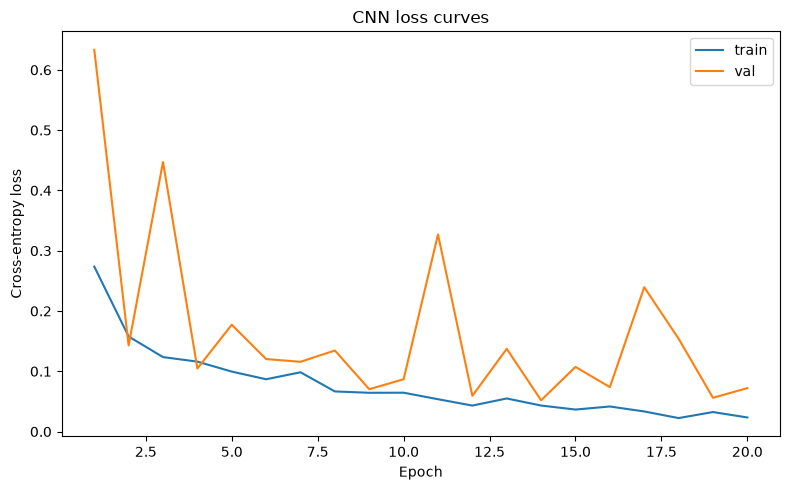

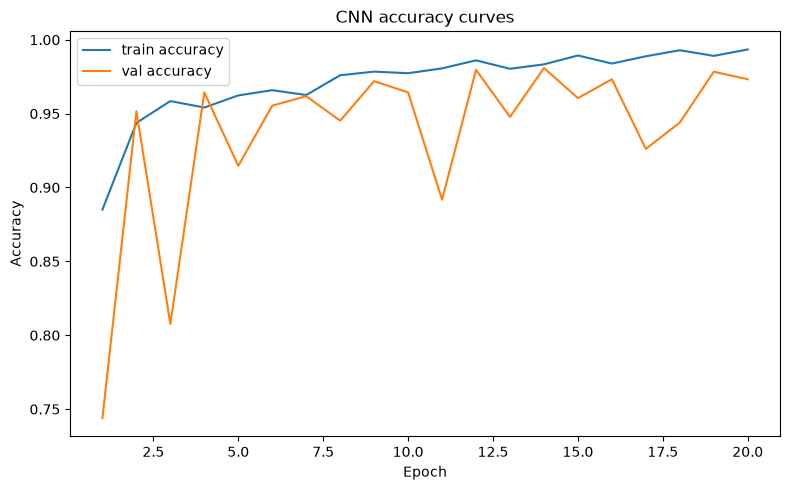

                  metric         value
0           val_accuracy      0.980892
1           val_macro_f1      0.974630
2  mean_time_per_epoch_s    110.387470
3   trainable_parameters  98178.000000
The baseline shows overfitting: training loss improved while validation performance stopped improving.
The widening train-validation gap indicates that the model is learning training-specific patterns.
The best checkpoint is selected at epoch 14 by minimum validation loss (0.0519).
At that epoch, validation accuracy is 0.981 and macro-F1 is 0.975.
Mean epoch time is 110.4 seconds and the model has 98,178 trainable parameters.
Day 2 uses no augmentation; later comparisons must reuse this fixed split and input normalization.


528

In [7]:
fig,ax=plt.subplots(figsize=(8,5)); ax.plot(history.epoch,history.train_loss,label="train"); ax.plot(history.epoch,history.val_loss,label="val"); ax.set(xlabel="Epoch",ylabel="Cross-entropy loss",title="CNN loss curves"); ax.legend(); fig.tight_layout(); fig.savefig(REPORTS_DIR/"cnn_loss_curves.png",dpi=150); plt.show()
fig,ax=plt.subplots(figsize=(8,5)); ax.plot(history.epoch,history.train_accuracy,label="train accuracy"); ax.plot(history.epoch,history.val_accuracy,label="val accuracy"); ax.set(xlabel="Epoch",ylabel="Accuracy",title="CNN accuracy curves"); ax.legend(); fig.tight_layout(); fig.savefig(REPORTS_DIR/"cnn_accuracy_curves.png",dpi=150); plt.show()
best=history.loc[history.val_loss.idxmin()]; baseline_metrics=pd.DataFrame([{ "metric":"val_accuracy", "value":best.val_accuracy }, { "metric":"val_macro_f1", "value":best.val_macro_f1 }, { "metric":"mean_time_per_epoch_s", "value":history.time_per_epoch_s.mean() }, { "metric":"trainable_parameters", "value":sum(p.numel() for p in model.parameters() if p.requires_grad) }]); baseline_metrics.to_csv(REPORTS_DIR / "baseline_metrics.csv", index=False); print(baseline_metrics)

train_loss_change=history.train_loss.iloc[0]-history.train_loss.iloc[-1]; val_loss_change=history.val_loss.iloc[0]-history.val_loss.iloc[-1]; accuracy_gap=history.train_accuracy.iloc[-1]-history.val_accuracy.iloc[-1]
if train_loss_change < 0.05 and val_loss_change < 0.05:
    diagnosis=["The baseline is underfitting: both training and validation loss changed very little.", "Training the model longer or increasing its capacity may be necessary."]
elif train_loss_change > 0.10 and (history.val_loss.iloc[-1] > history.val_loss.min() * 1.05 or accuracy_gap > 0.10):
    diagnosis=["The baseline shows overfitting: training loss improved while validation performance stopped improving.", "The widening train-validation gap indicates that the model is learning training-specific patterns."]
else:
    diagnosis=["The baseline is reasonably healthy: training and validation curves improve together.", "The validation curve is close enough to the training curve that there is no large overfitting gap."]
diagnosis += [f"The best checkpoint is selected at epoch {int(best.epoch)} by minimum validation loss ({best.val_loss:.4f}).", f"At that epoch, validation accuracy is {best.val_accuracy:.3f} and macro-F1 is {best.val_macro_f1:.3f}.", f"Mean epoch time is {history.time_per_epoch_s.mean():.1f} seconds and the model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters.", "Day 2 uses no augmentation; later comparisons must reuse this fixed split and input normalization."]
diagnosis_text="\n".join(diagnosis); print(diagnosis_text); (REPORTS_DIR / "cnn_diagnosis.txt").write_text(diagnosis_text, encoding="utf-8")

## Diagnosis

The generated diagnosis below the plots classifies the baseline as underfitting, overfitting, or reasonably healthy using the loss curves and train-validation accuracy gap. It also records the best validation-loss epoch, validation accuracy, macro-F1, mean epoch time, and trainable parameter count. The saved best checkpoint is selected by validation loss, not by a noisy single accuracy value.